In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import utils_data
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('../../models/baselines/odmd_kind_sim.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=50, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=400, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=12, out_features=12, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=50, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
   

Parameter containing:
tensor([[ 3.2794e-02, -7.4463e-02, -1.7207e-01, -1.5579e-01,  2.3750e-05,
         -2.1616e-01, -2.2580e-01,  5.7701e-02,  5.2938e-02, -2.3936e-01,
          1.3470e-03,  1.9204e-01],
        [ 9.4635e-03, -4.6407e-02, -3.2313e-01, -1.6011e-01,  1.0508e-04,
         -2.4964e-02, -2.1244e-01,  1.5621e-01,  3.2013e-02, -2.6349e-01,
         -2.6111e-02,  1.6976e-01],
        [ 3.4269e-02,  4.3295e-03,  3.1933e-01,  1.8352e-01, -1.2501e-05,
         -1.9345e-01, -3.0345e-01,  3.5889e-01, -3.2566e-01, -3.2638e-01,
          6.8093e-03,  4.4370e-01],
        [ 2.4320e-01,  2.3776e-01,  2.1134e-01,  8.0323e-01,  3.9491e-04,
          4.5027e-01, -3.8152e-01,  1.5475e-01, -1.0191e-01, -2.5243e-01,
         -1.4117e-01,  3.0024e-01],
        [-1.7031e-04,  3.8043e-04, -2.2122e-04,  1.9788e-04,  1.2890e-07,
          1.9055e-04, -2.1137e-04, -1.1671e-04,  1.0571e-04,  2.6383e-05,
         -3.9082e-05, -6.5096e-05],
        [ 1.4889e-01,  2.1478e-01, -2.3087e-01,  2.5680e-0

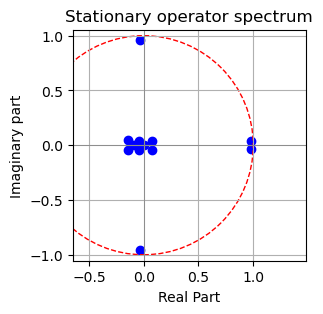

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

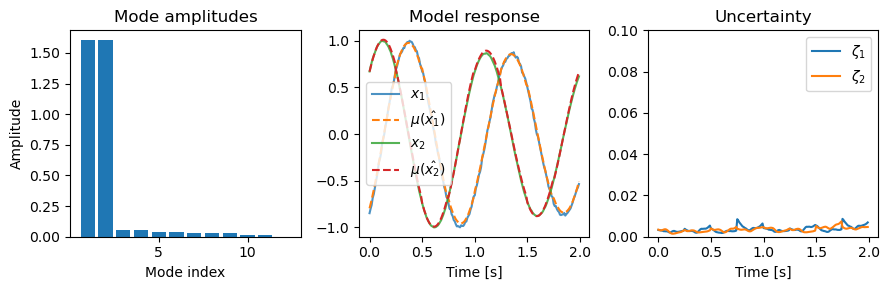

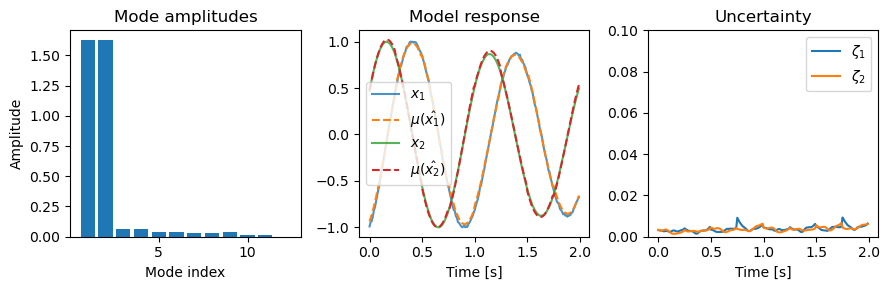

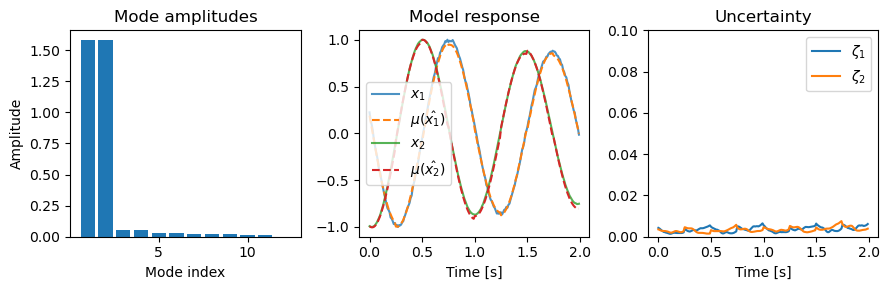

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/baselines/train_sim_stat'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

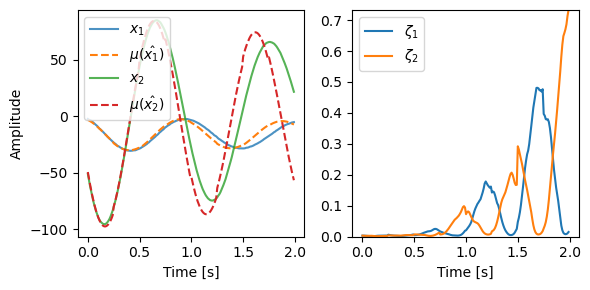

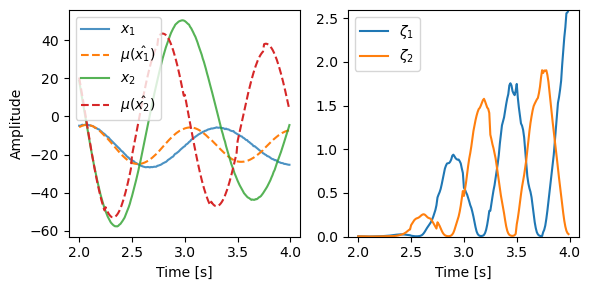

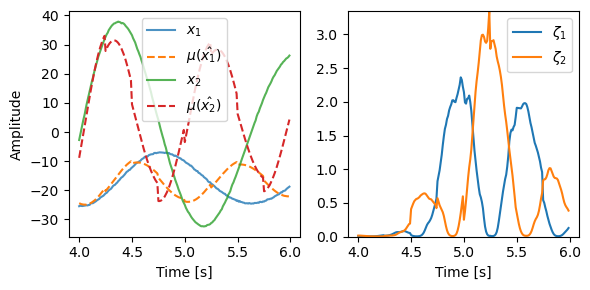

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a stationary model

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_stationary(model, datadir, timeseries_nsample, datasaved=False)

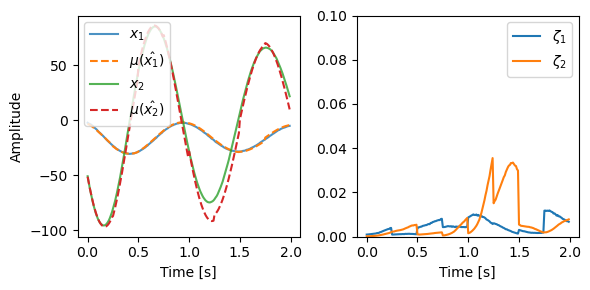

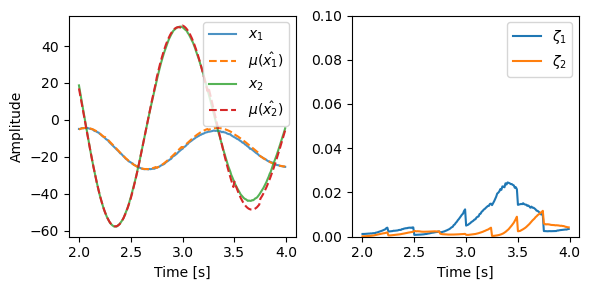

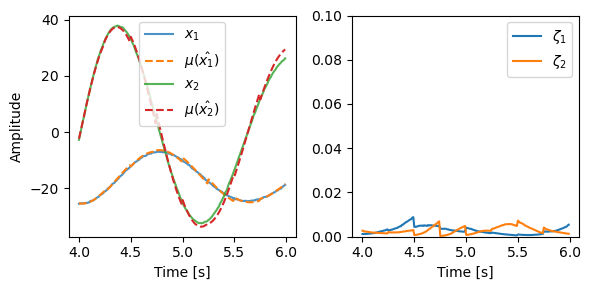

In [7]:
# --!--------------------------------------------------------------------------
# --! evaluate a transient model

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_transient(model, datadir, timeseries_nsample, datasaved=False)

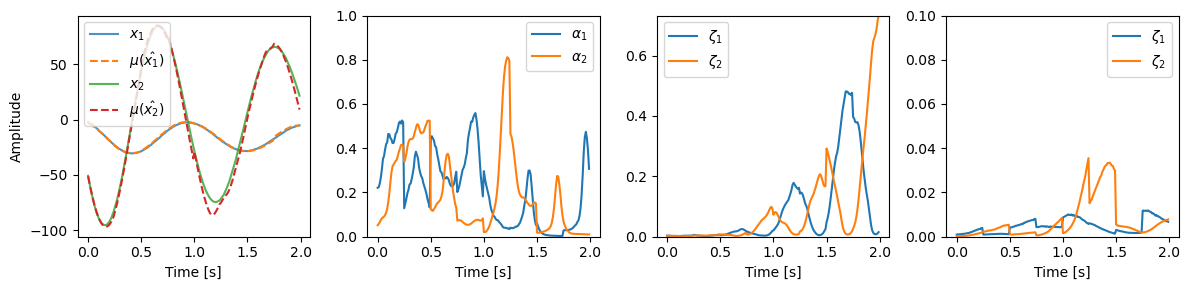

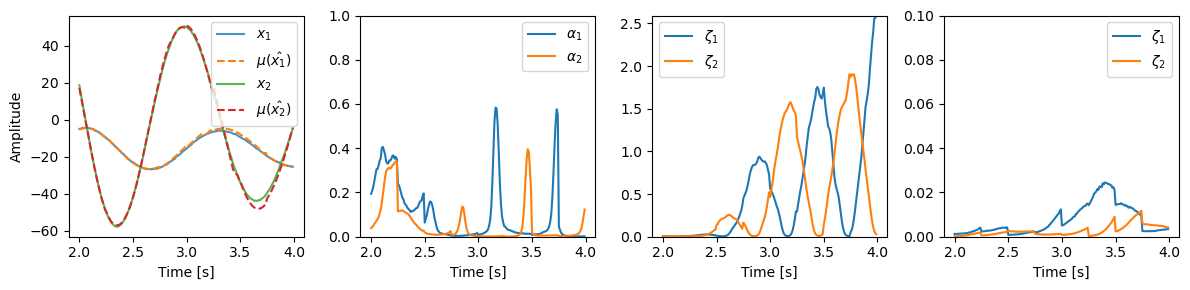

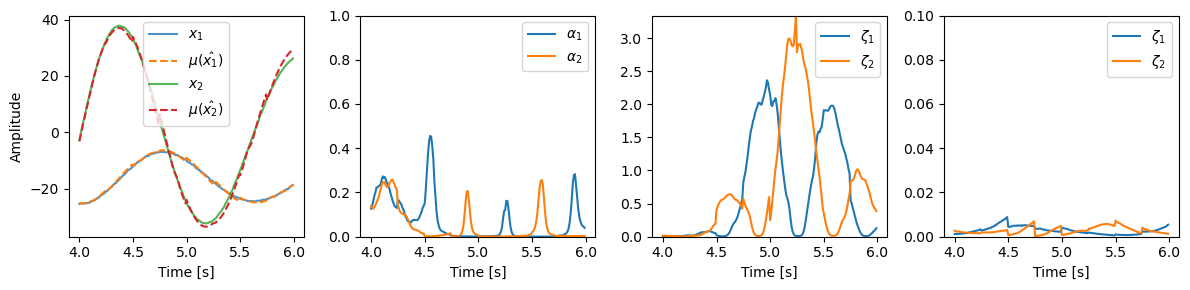

In [8]:
# --!--------------------------------------------------------------------------
# --! test alpha blending

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_blend(model, datadir, timeseries_nsample, datasaved=False)